In [1]:
from pathlib import Path
import sys
import pandas as pd
!{sys.executable} -m pip install duckdb

current = Path.cwd()

PROJECT_ROOT = next(
    (
        directory
        for directory in [current, *current.parents]
        if (directory / "config.py").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find config.py in the current directory or its parents."
    )

sys.path.insert(0, str(PROJECT_ROOT))
from src.data import *
from config import *
from src.plotting import *
from src.database import *



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
!python '../scripts/build_database.py'
# %pwd

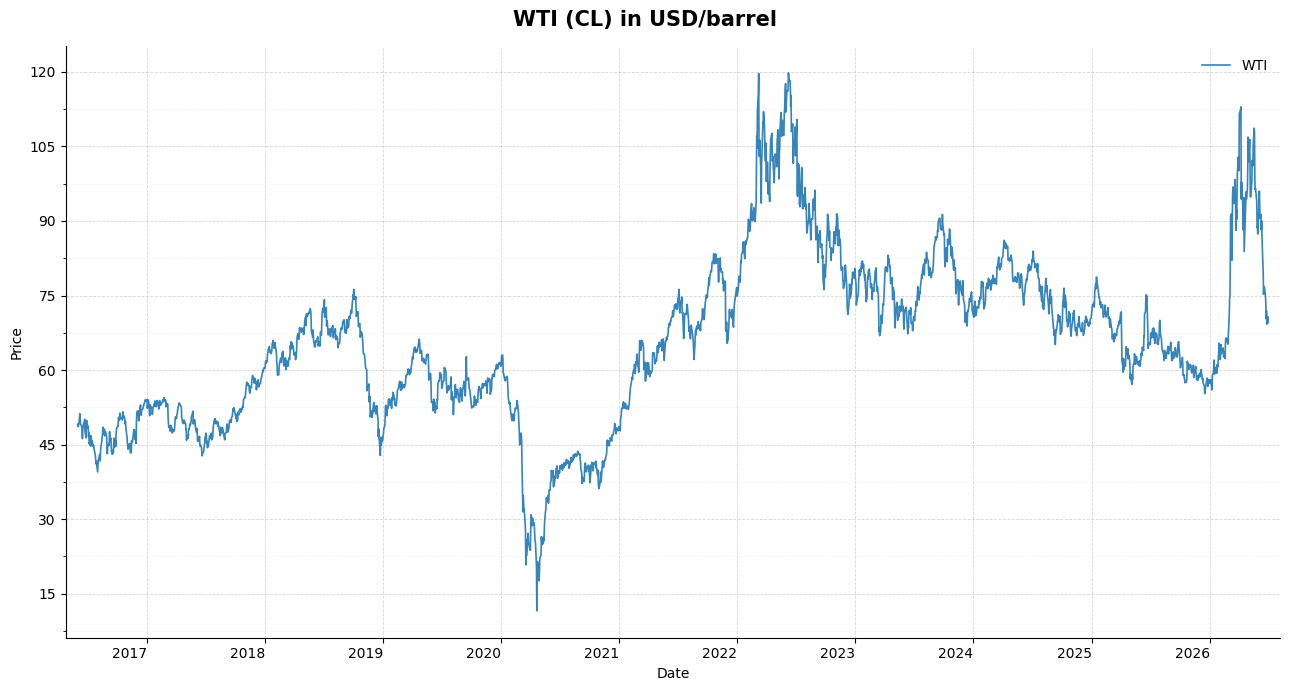

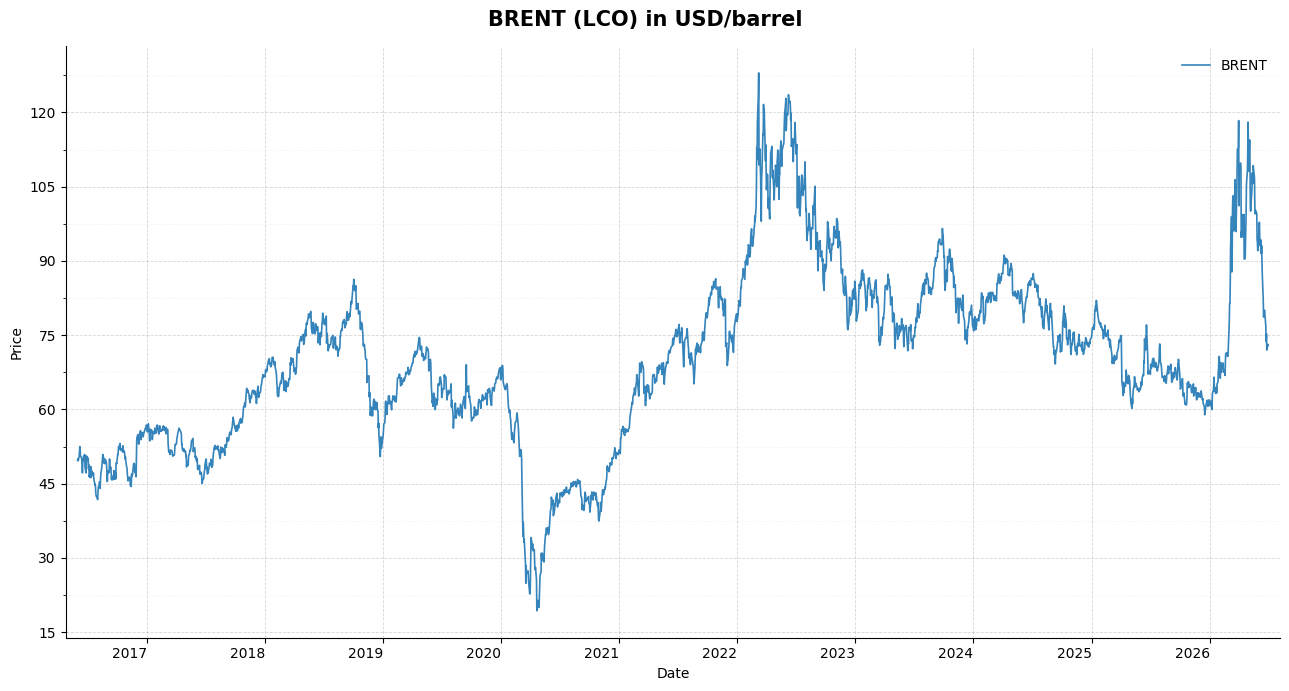

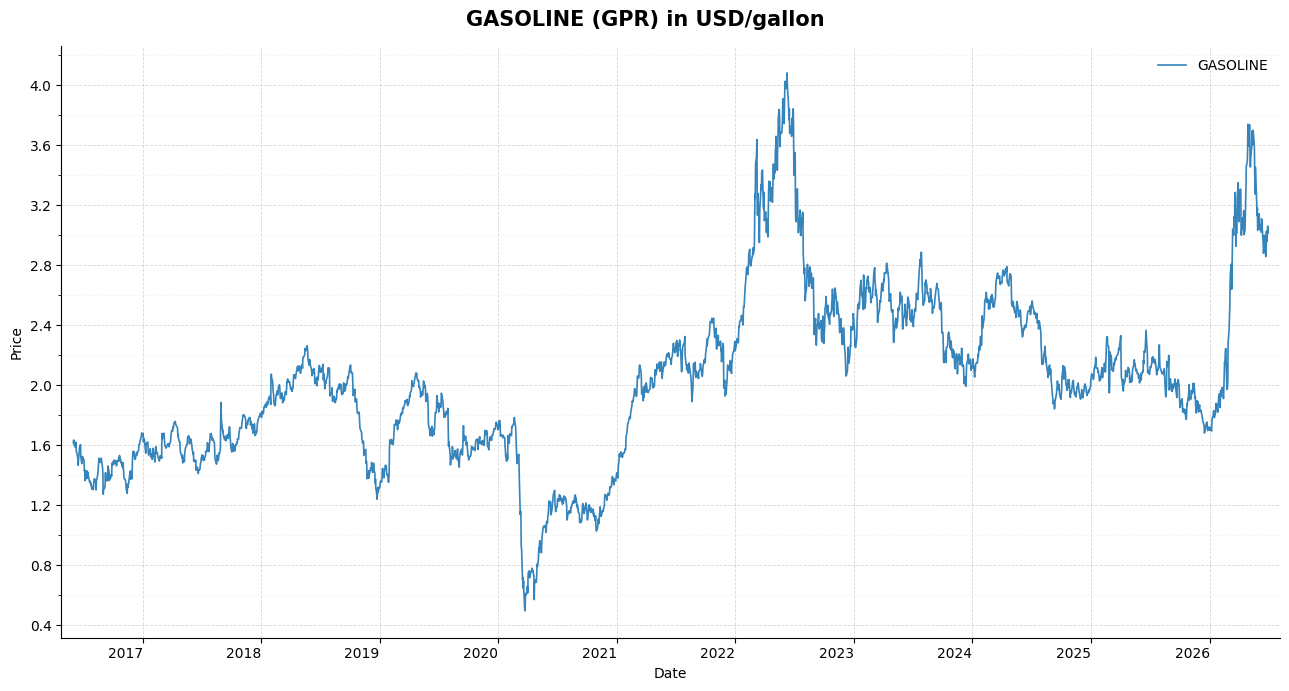

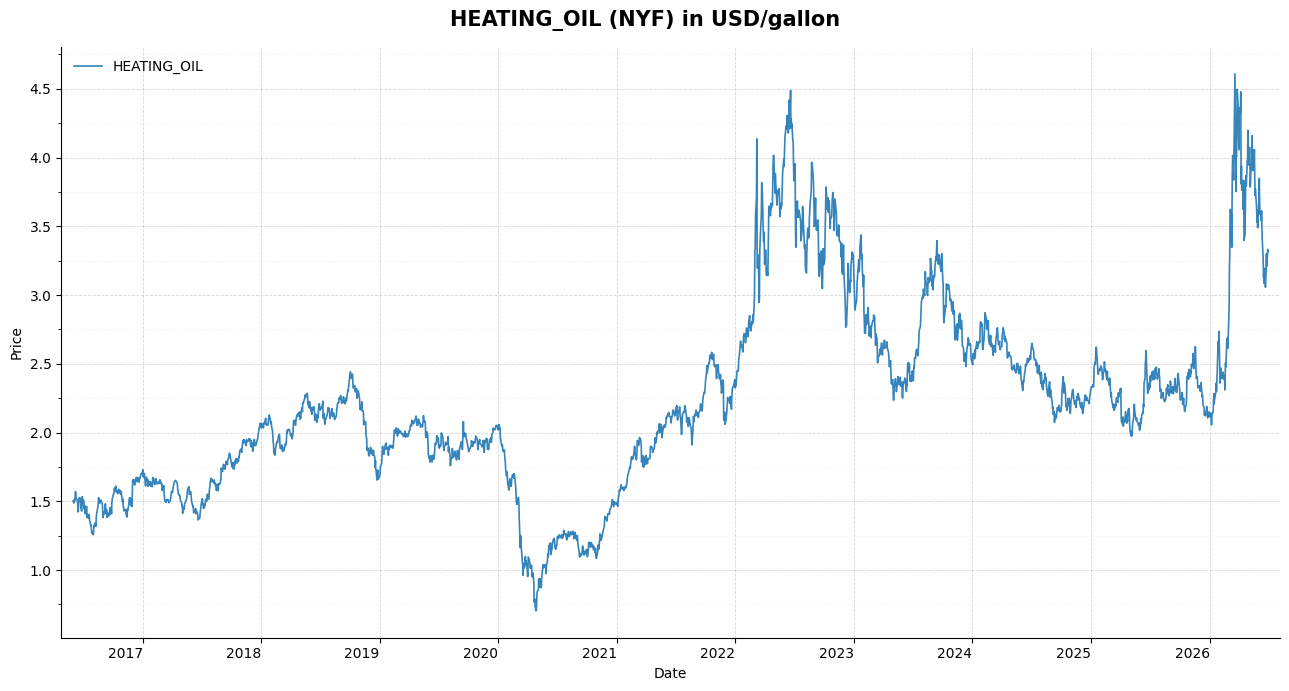

In [3]:
connection = db_connect()

# test = db_query(connection, """
#                 SELECT date, BRENT - WTI as transatlantic
#                 FROM market_prices
#                 ;  
# """)

# brent = db_query(connection, """
#                 SELECT date, BRENT
#                  FROM market_prices;
# """)

# wti = db_query(connection, """
#                 SELECT date, WTI
#                FROM market_prices;
# """)

# gasoline = db_query(connection, """
#                 SELECT date, GASOLINE,
#                 FROM market_prices;
# """)

# heating_oil = db_query(connection, """
#                 SELECT date, HEATING_OIL,
#                 FROM market_prices;
# """)

## display graph seperately
for instrument, metadata in INSTRUMENTS.items():
    df = db_query(connection, f"""
                SELECT date, {instrument}
                FROM market_prices;
""")
    plot_historical_prices(f'{instrument} ({metadata['ticker']}) in {metadata['units']}',
                           df,
                           instrument,
                           f'{FIGURES_DIR / instrument}.png',
                           date_frequency='yearly')


connection.close()

# display(
#     plot_historical_prices('brent', brent, ['BRENT'], FIGURES_DIR / 'brent.png', date_frequency='yearly'),
#     plot_historical_prices('wti', wti, ['WTI'], FIGURES_DIR / 'wti.png', date_frequency='yearly'),
#     plot_historical_prices('gasoline', gasoline, ['GASOLINE'], FIGURES_DIR / 'gasoline.png', date_frequency='yearly'),
#     plot_historical_prices('heating_oil', heating_oil, ['HEATING_OIL'], FIGURES_DIR / 'heating_oil.png', date_frequency='yearly')
# )

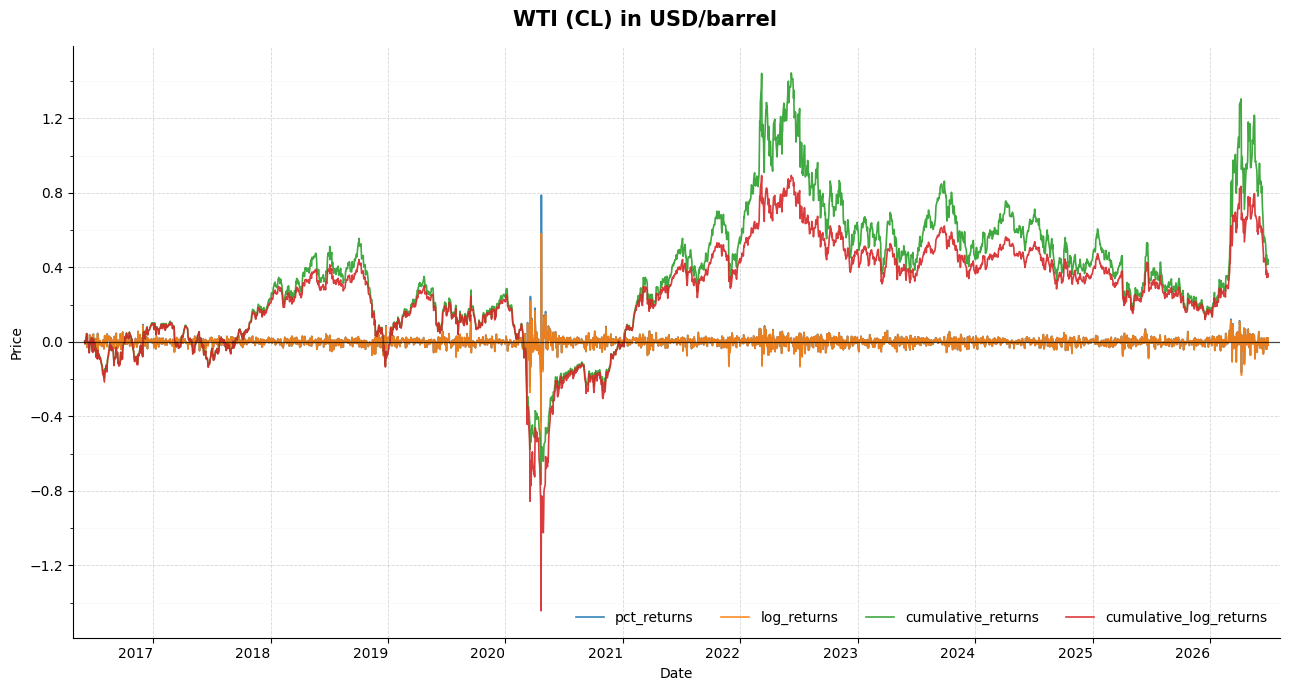

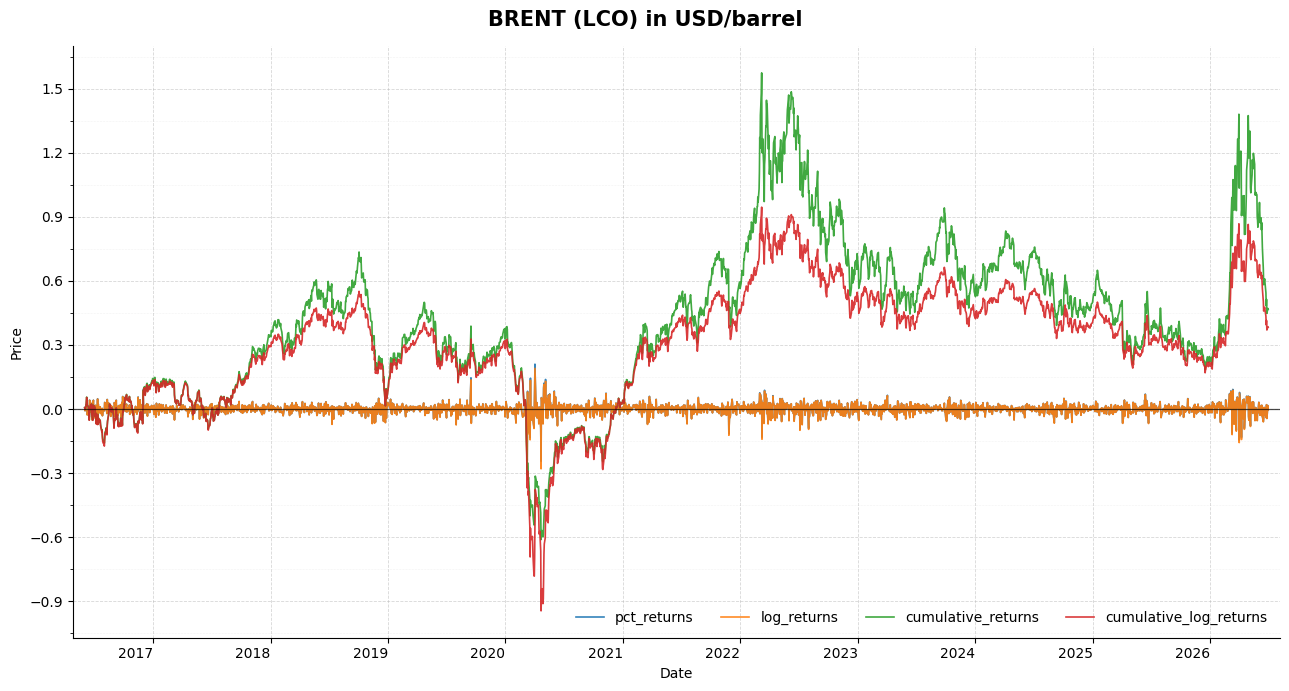

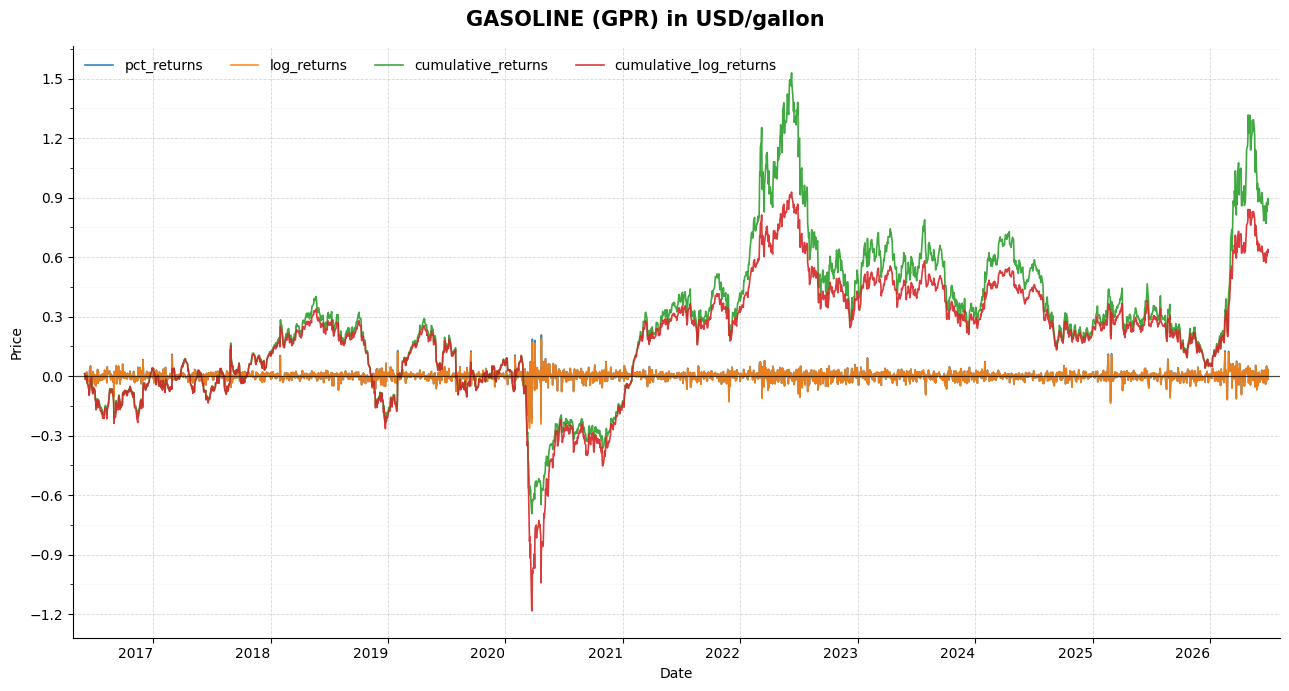

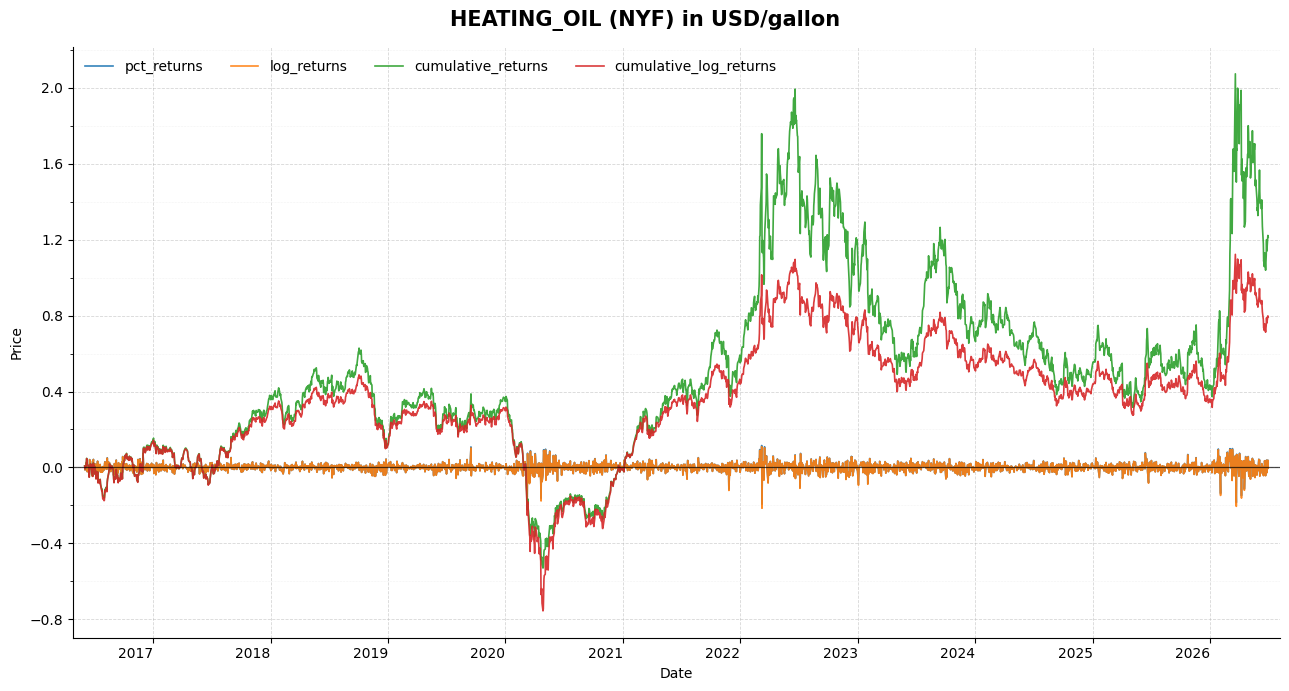

In [4]:
## all simple returns
from src.returns import *

connection = db_connect()
for instrument, metadata in INSTRUMENTS.items():
    df = db_query(connection, f"""
                SELECT date, {instrument}
                FROM market_prices;
""")
    df_returns = df.copy()
    df_returns['pct_returns'] = calculate_simple_returns(df_returns[instrument])
    df_returns['log_returns'] = calculate_log_returns(df_returns[instrument])
    df_returns['cumulative_returns'] = calculate_cumulative_returns(df_returns['pct_returns'])
    df_returns['cumulative_log_returns'] = calculate_cumulative_log_returns(df_returns['log_returns'])
    plot_historical_prices(f'{instrument} ({metadata['ticker']}) in {metadata['units']}',
                           df_returns,
                           ['pct_returns', 'log_returns', 'cumulative_returns', 'cumulative_log_returns'],
                           f'{FIGURES_DIR / 'returns'/ instrument}_returns.png',
                           date_frequency='yearly')
    
    
    
connection.close()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


0            NaN
1       0.203228
2       0.362293
3       0.191667
4       0.419451
          ...   
2592         NaN
2593         NaN
2594         NaN
2595         NaN
2596         NaN
Name: cumulative_log_returns, Length: 2597, dtype: float64


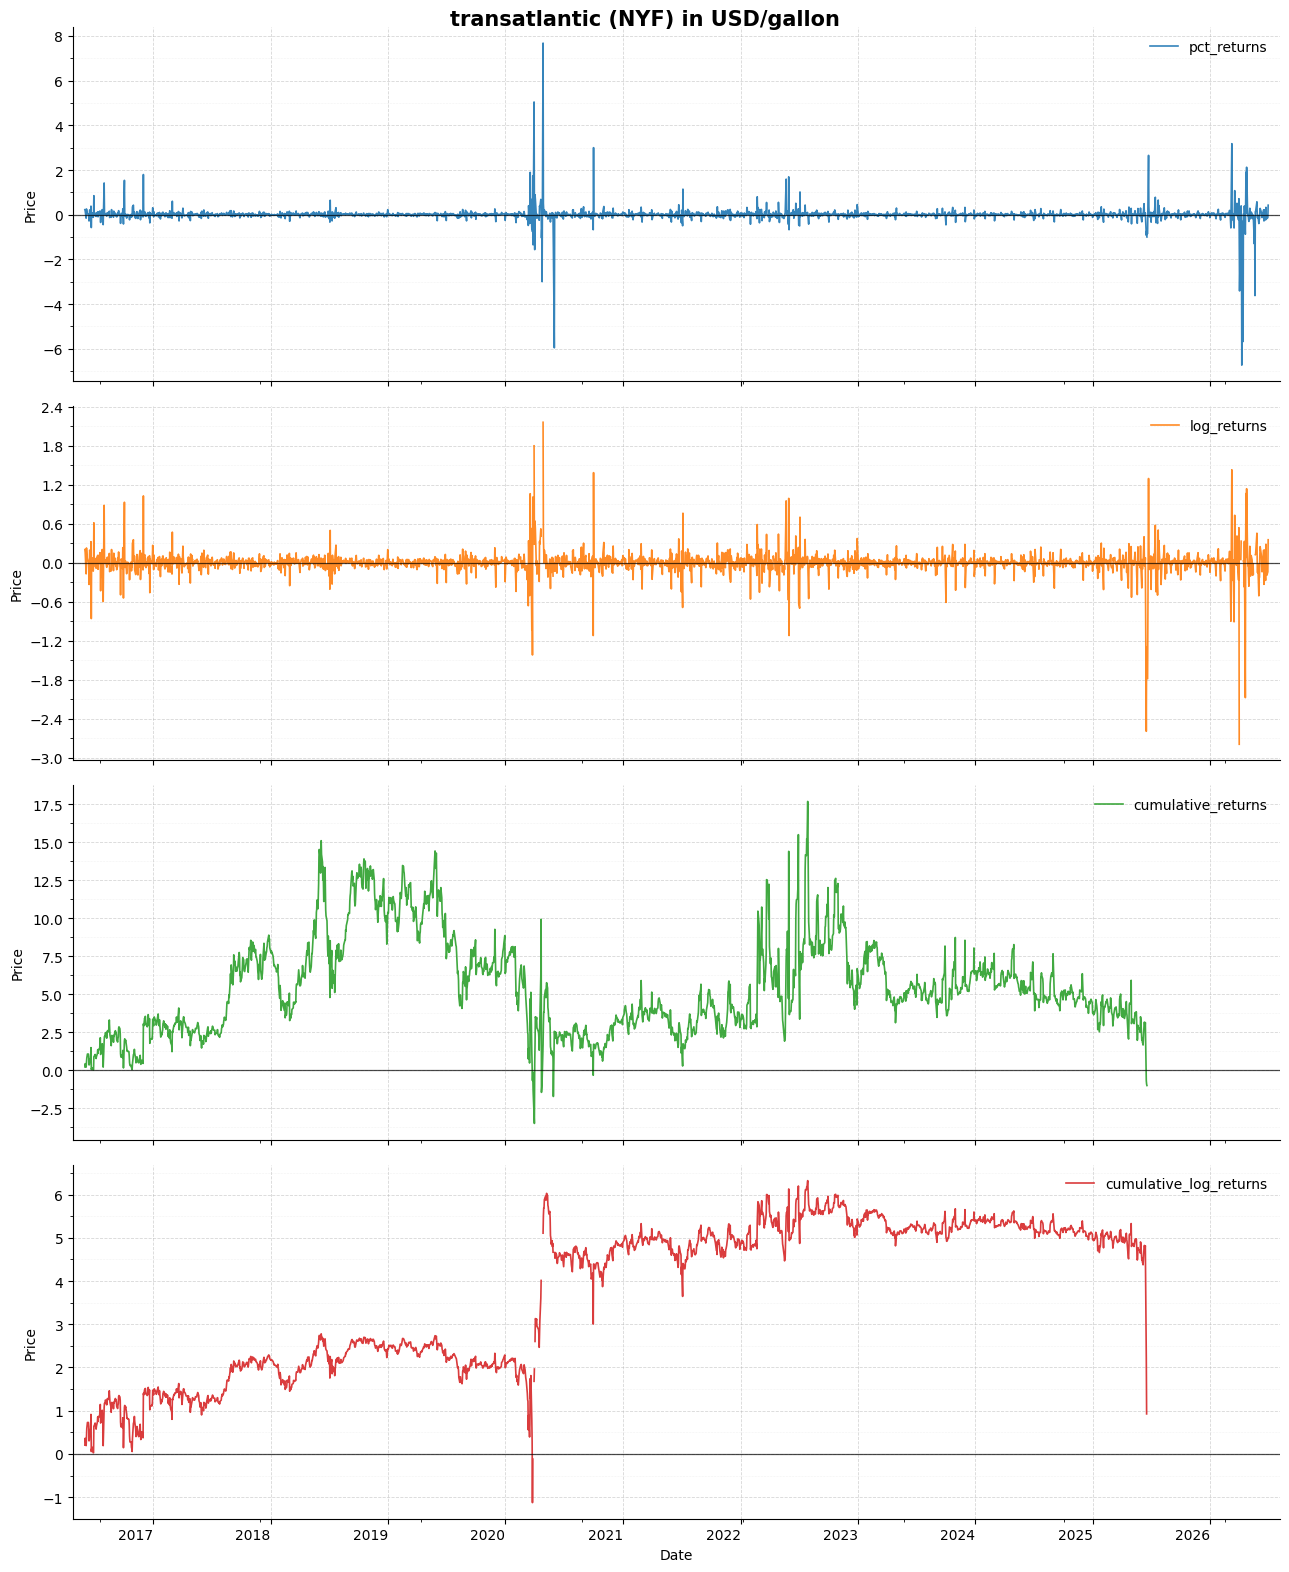

In [5]:
connection = db_connect()
instrument = 'transatlantic'
df = db_query(connection,
           """
            SELECT date, BRENT - WTI AS transatlantic
            FROM market_prices
            WHERE BRENT IS NOT NULL AND WTI IS NOT NULL;
"""   
              )
df_returns = df.copy()
df_returns['pct_returns'] = calculate_simple_returns(df_returns[instrument])
df_returns['log_returns'] = calculate_log_returns(df_returns[instrument])
df_returns['cumulative_returns'] = calculate_cumulative_returns(df_returns['pct_returns'])
df_returns['cumulative_log_returns'] = calculate_cumulative_log_returns(df_returns['log_returns'])

print(df_returns['cumulative_log_returns'])

plot_historical_prices(f'{instrument} ({metadata['ticker']}) in {metadata['units']}',
                        df_returns,
                        ['pct_returns', 'log_returns', 'cumulative_returns', 'cumulative_log_returns'],
                        f'{FIGURES_DIR / 'returns'/ instrument}_returns.png', True,
                        date_frequency='yearly')
    

connection.close()